In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hubdata

from copula import (
    calculate_pit,
    fit_copula,
    generate_copula_trajectories,
    generate_trajectories_for_date,
    plot_all_copula_trajectories
)
%load_ext autoreload
%autoreload 2

In [2]:
# Project path
project_path = "/Users/dk29776/Dropbox/UTAustin/City-Level-Forecasting/GBQR-extensions"
os.chdir(project_path)

# Flu-MetroCast Hub
hub_path = "/Users/dk29776/Dropbox/UTAustin/flu-metrocast"

print("Working directory:", os.getcwd())
print("Hub path:", hub_path)

# Connect to hub
hub = hubdata.connect_hub(hub_path)

print(hub)

Working directory: /Users/dk29776/Dropbox/UTAustin/City-Level-Forecasting/GBQR-extensions
Hub path: /Users/dk29776/Dropbox/UTAustin/flu-metrocast


In [3]:
table = hub.to_table()

In [4]:
predictions = table.to_pandas()

predictions["model_id"].unique()

array(['ACCIDDA-InfluPaint', 'FluSight-ensemble', 'MOBS-EpyStrain_Flu',
       'NAU-Copycat', 'NAU-INFLAenza', 'UMass-SAR', 'UMass-alloy',
       'UT-GBQR', 'VTSanghani-PRIME', 'epiENGAGE-Copycat',
       'epiENGAGE-GBQR', 'epiENGAGE-INFLAenza', 'epiENGAGE-baseline',
       'epiENGAGE-ensemble_mean', 'epiENGAGE-lop_norm',
       'epiforecasts-dyngam'], dtype=object)

In [5]:
gbqr = predictions[
    (predictions["model_id"] == "UT-GBQR") &
    (predictions["output_type"] == "quantile")
].copy()

print(gbqr.shape)
gbqr.head()

(70272, 9)


,reference_date,target,horizon,location,target_end_date,output_type,output_type_id,value,model_id
343764,2025-11-22,Flu ED visits pct,0,denver,2025-11-22,quantile,0.025,0.201989,UT-GBQR
343765,2025-11-22,Flu ED visits pct,0,colorado-springs,2025-11-22,quantile,0.025,0.061791,UT-GBQR
343766,2025-11-22,Flu ED visits pct,0,weld,2025-11-22,quantile,0.025,0.101829,UT-GBQR
343767,2025-11-22,Flu ED visits pct,0,colorado,2025-11-22,quantile,0.025,0.117788,UT-GBQR
343768,2025-11-22,Flu ED visits pct,0,mesa,2025-11-22,quantile,0.025,0.000000,UT-GBQR


In [6]:
observed = pd.read_csv(
    os.path.join(
        hub_path,
        "target-data",
        "oracle-output.csv"
    )
)

print(observed.shape)
observed.head()

(2326, 4)


,target_end_date,location,target,oracle_value
0,2025-11-22,nyc,ILI ED visits pct,3.69
1,2025-11-29,nyc,ILI ED visits pct,5.68
2,2025-11-22,denver,Flu ED visits pct,2.00
3,2025-11-22,larimer,Flu ED visits pct,0.81
4,2025-11-22,mesa,Flu ED visits pct,0.37


In [7]:
# Make sure dates have the same type
gbqr["target_end_date"] = pd.to_datetime(
    gbqr["target_end_date"]
)

observed["target_end_date"] = pd.to_datetime(
    observed["target_end_date"]
)

# Merge observed values onto UT-GBQR forecasts
gbqr_obs = gbqr.merge(
    observed,
    on=["location", "target", "target_end_date"],
    how="left"
)

print(gbqr_obs.shape)
gbqr_obs.head()

(70272, 10)


,reference_date,target,horizon,location,target_end_date,output_type,output_type_id,value,model_id,oracle_value
0,2025-11-22,Flu ED visits pct,0,denver,2025-11-22,quantile,0.025,0.201989,UT-GBQR,2.00
1,2025-11-22,Flu ED visits pct,0,colorado-springs,2025-11-22,quantile,0.025,0.061791,UT-GBQR,1.02
2,2025-11-22,Flu ED visits pct,0,weld,2025-11-22,quantile,0.025,0.101829,UT-GBQR,2.68
3,2025-11-22,Flu ED visits pct,0,colorado,2025-11-22,quantile,0.025,0.117788,UT-GBQR,1.72
4,2025-11-22,Flu ED visits pct,0,mesa,2025-11-22,quantile,0.025,0.000000,UT-GBQR,0.37


In [8]:
pit_df = (
    gbqr_obs
    .groupby(
        ["reference_date", "location", "horizon"],
        as_index=False
    )
    .apply(calculate_pit)
    .reset_index(drop=True)
)

pit_df.head()

,reference_date,location,horizon,pit,z,oracle_value
0,2025-11-22,athens,0,0.366180,-0.341988,1.38
1,2025-11-22,athens,1,0.438456,-0.154885,1.75
2,2025-11-22,athens,2,0.551092,0.128420,2.29
3,2025-11-22,athens,3,0.750996,0.677626,4.38
4,2025-11-22,austin,0,0.538067,0.095565,0.96


In [9]:
# Reshape latent z values into one row per forecast origin/location
z_wide = (
    pit_df
    .pivot(
        index=["reference_date", "location"],
        columns="horizon",
        values="z"
    )
    .reset_index()
)

z_wide.columns.name = None

# Horizon columns
horizons = sorted(pit_df["horizon"].unique())

# Keep complete trajectories
z_complete = z_wide.dropna(subset=horizons)

Z = z_complete[horizons].to_numpy()

print("z_wide shape:", z_wide.shape)
print("Z shape:", Z.shape)
print("Horizons:", horizons)

z_wide shape: (1952, 6)
Z shape: (1952, 4)
Horizons: [0, 1, 2, 3]


In [10]:
Sigma_hat, xi_hat, fit = fit_copula(Z)

print("Optimization success:", fit.success)
print("xi_hat:", xi_hat)
print("Sigma_hat:")
print(Sigma_hat)

Optimization success: True
xi_hat: [0.58472421 0.33718663 0.11333532]
Sigma_hat:
[[1.         0.58472421 0.33718663 0.11333532]
 [0.58472421 1.         0.58472421 0.33718663]
 [0.33718663 0.58472421 1.         0.58472421]
 [0.11333532 0.33718663 0.58472421 1.        ]]


In [11]:
example_date = gbqr["reference_date"].min()
example_location = "denver"

example_fcst = (
    gbqr[
        (gbqr["reference_date"] == example_date) &
        (gbqr["location"] == example_location)
    ]
    .copy()
)

print("Reference date:", example_date)
print("Location:", example_location)
print("Horizons:", sorted(example_fcst["horizon"].unique()))

Reference date: 2025-11-22
Location: denver
Horizons: [0, 1, 2, 3]


In [12]:
Y_sim = generate_copula_trajectories(
    forecast=example_fcst,
    Sigma=Sigma_hat,
    n_trajectories=100,
    seed=123
)

print("Y_sim shape:", Y_sim.shape)
print("Negative values:", (Y_sim < 0).sum())
print(Y_sim[:5])

Y_sim shape: (100, 4)
Negative values: 0
[[1.90294451 3.29982074 3.05885059 2.54878156]
 [1.88893967 1.75032948 0.70416347 1.59370296]
 [1.95847631 2.02775796 2.80500734 2.44652242]
 [0.46016862 1.35526487 1.73908802 1.58015188]
 [0.66557423 0.56860071 0.69018739 1.89720198]]


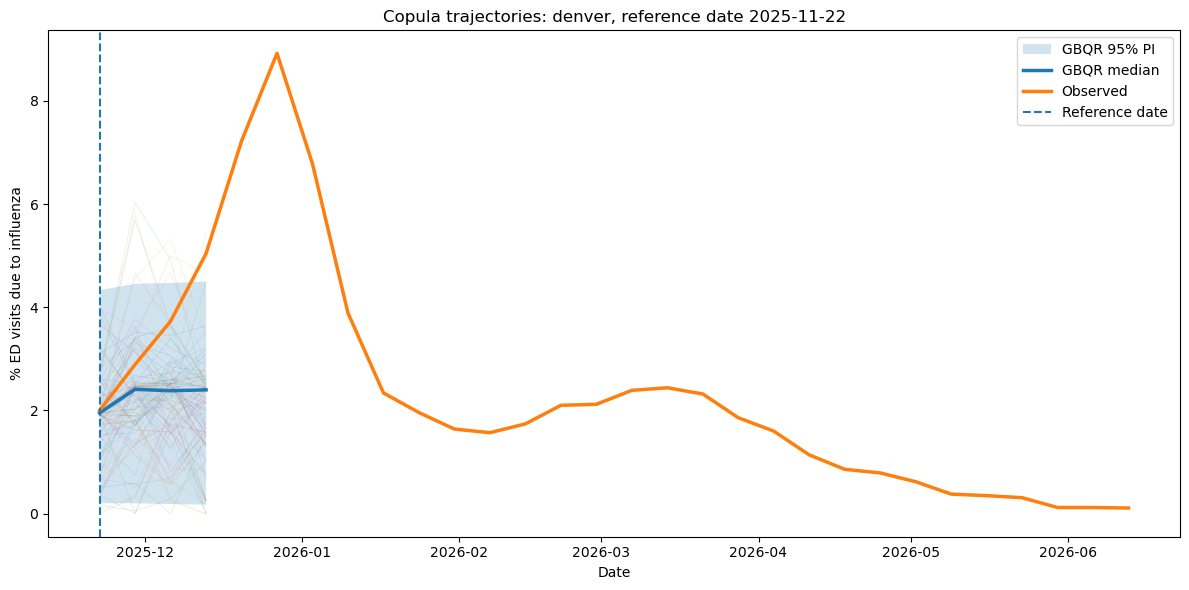

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Denver observed data
obs_plot = (
    observed[
        (observed["location"] == example_location) &
        (observed["target"] == example_fcst["target"].iloc[0])
    ]
    .sort_values("target_end_date")
    .copy()
)

# Target dates corresponding to horizons 0-3
target_dates = (
    example_fcst[
        ["horizon", "target_end_date"]
    ]
    .drop_duplicates()
    .sort_values("horizon")["target_end_date"]
    .to_numpy()
)

# 95% PI from original GBQR forecast
lower95 = (
    example_fcst[
        example_fcst["output_type_id"].astype(float) == 0.025
    ]
    .sort_values("horizon")["value"]
    .to_numpy()
)

upper95 = (
    example_fcst[
        example_fcst["output_type_id"].astype(float) == 0.975
    ]
    .sort_values("horizon")["value"]
    .to_numpy()
)

# GBQR median
median = (
    example_fcst[
        example_fcst["output_type_id"].astype(float) == 0.5
    ]
    .sort_values("horizon")["value"]
    .to_numpy()
)

fig, ax = plt.subplots(figsize=(12, 6))

# 95% PI
ax.fill_between(
    target_dates,
    lower95,
    upper95,
    alpha=0.20,
    label="GBQR 95% PI"
)

# Copula trajectories
for i in range(min(100, Y_sim.shape[0])):
    ax.plot(
        target_dates,
        Y_sim[i, :],
        linewidth=0.7,
        alpha=0.12
    )

# GBQR median
ax.plot(
    target_dates,
    median,
    linewidth=2.5,
    label="GBQR median"
)

# Observed
ax.plot(
    obs_plot["target_end_date"],
    obs_plot["oracle_value"],
    linewidth=2.5,
    label="Observed"
)

# Reference date
ax.axvline(
    pd.to_datetime(example_date),
    linestyle="--",
    linewidth=1.5,
    label="Reference date"
)

ax.set_xlabel("Date")
ax.set_ylabel("% ED visits due to influenza")

ax.set_title(
    f"Copula trajectories: {example_location}, "
    f"reference date {pd.to_datetime(example_date).date()}"
)

ax.legend()

plt.tight_layout()
plt.show()

In [14]:
example_date = gbqr["reference_date"].min()

trajectories = generate_trajectories_for_date(
    forecasts=gbqr,
    reference_date=example_date,
    Sigma=Sigma_hat,
    n_trajectories=100,
    seed=123
)

print(trajectories.shape)
trajectories.head()

(27200, 6)


,horizon,target_end_date,reference_date,location,trajectory_id,value
0,0,2025-11-22,2025-11-22,athens,0,2.099827
1,1,2025-11-29,2025-11-22,athens,0,7.887287
2,2,2025-12-06,2025-11-22,athens,0,7.884082
3,3,2025-12-13,2025-11-22,athens,0,3.440714
4,0,2025-11-22,2025-11-22,athens,1,2.045654


In [15]:
output_dir = os.path.join(
    project_path,
    "model-output",
    "2627test"
)

os.makedirs(output_dir, exist_ok=True)

date_string = pd.to_datetime(example_date).strftime("%Y-%m-%d")

output_path = os.path.join(
    output_dir,
    f"{date_string}-UT-GBQR.parquet"
)

trajectories.to_parquet(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: /Users/dk29776/Dropbox/UTAustin/City-Level-Forecasting/GBQR-extensions/model-output/2627test/2025-11-22-UT-GBQR.parquet


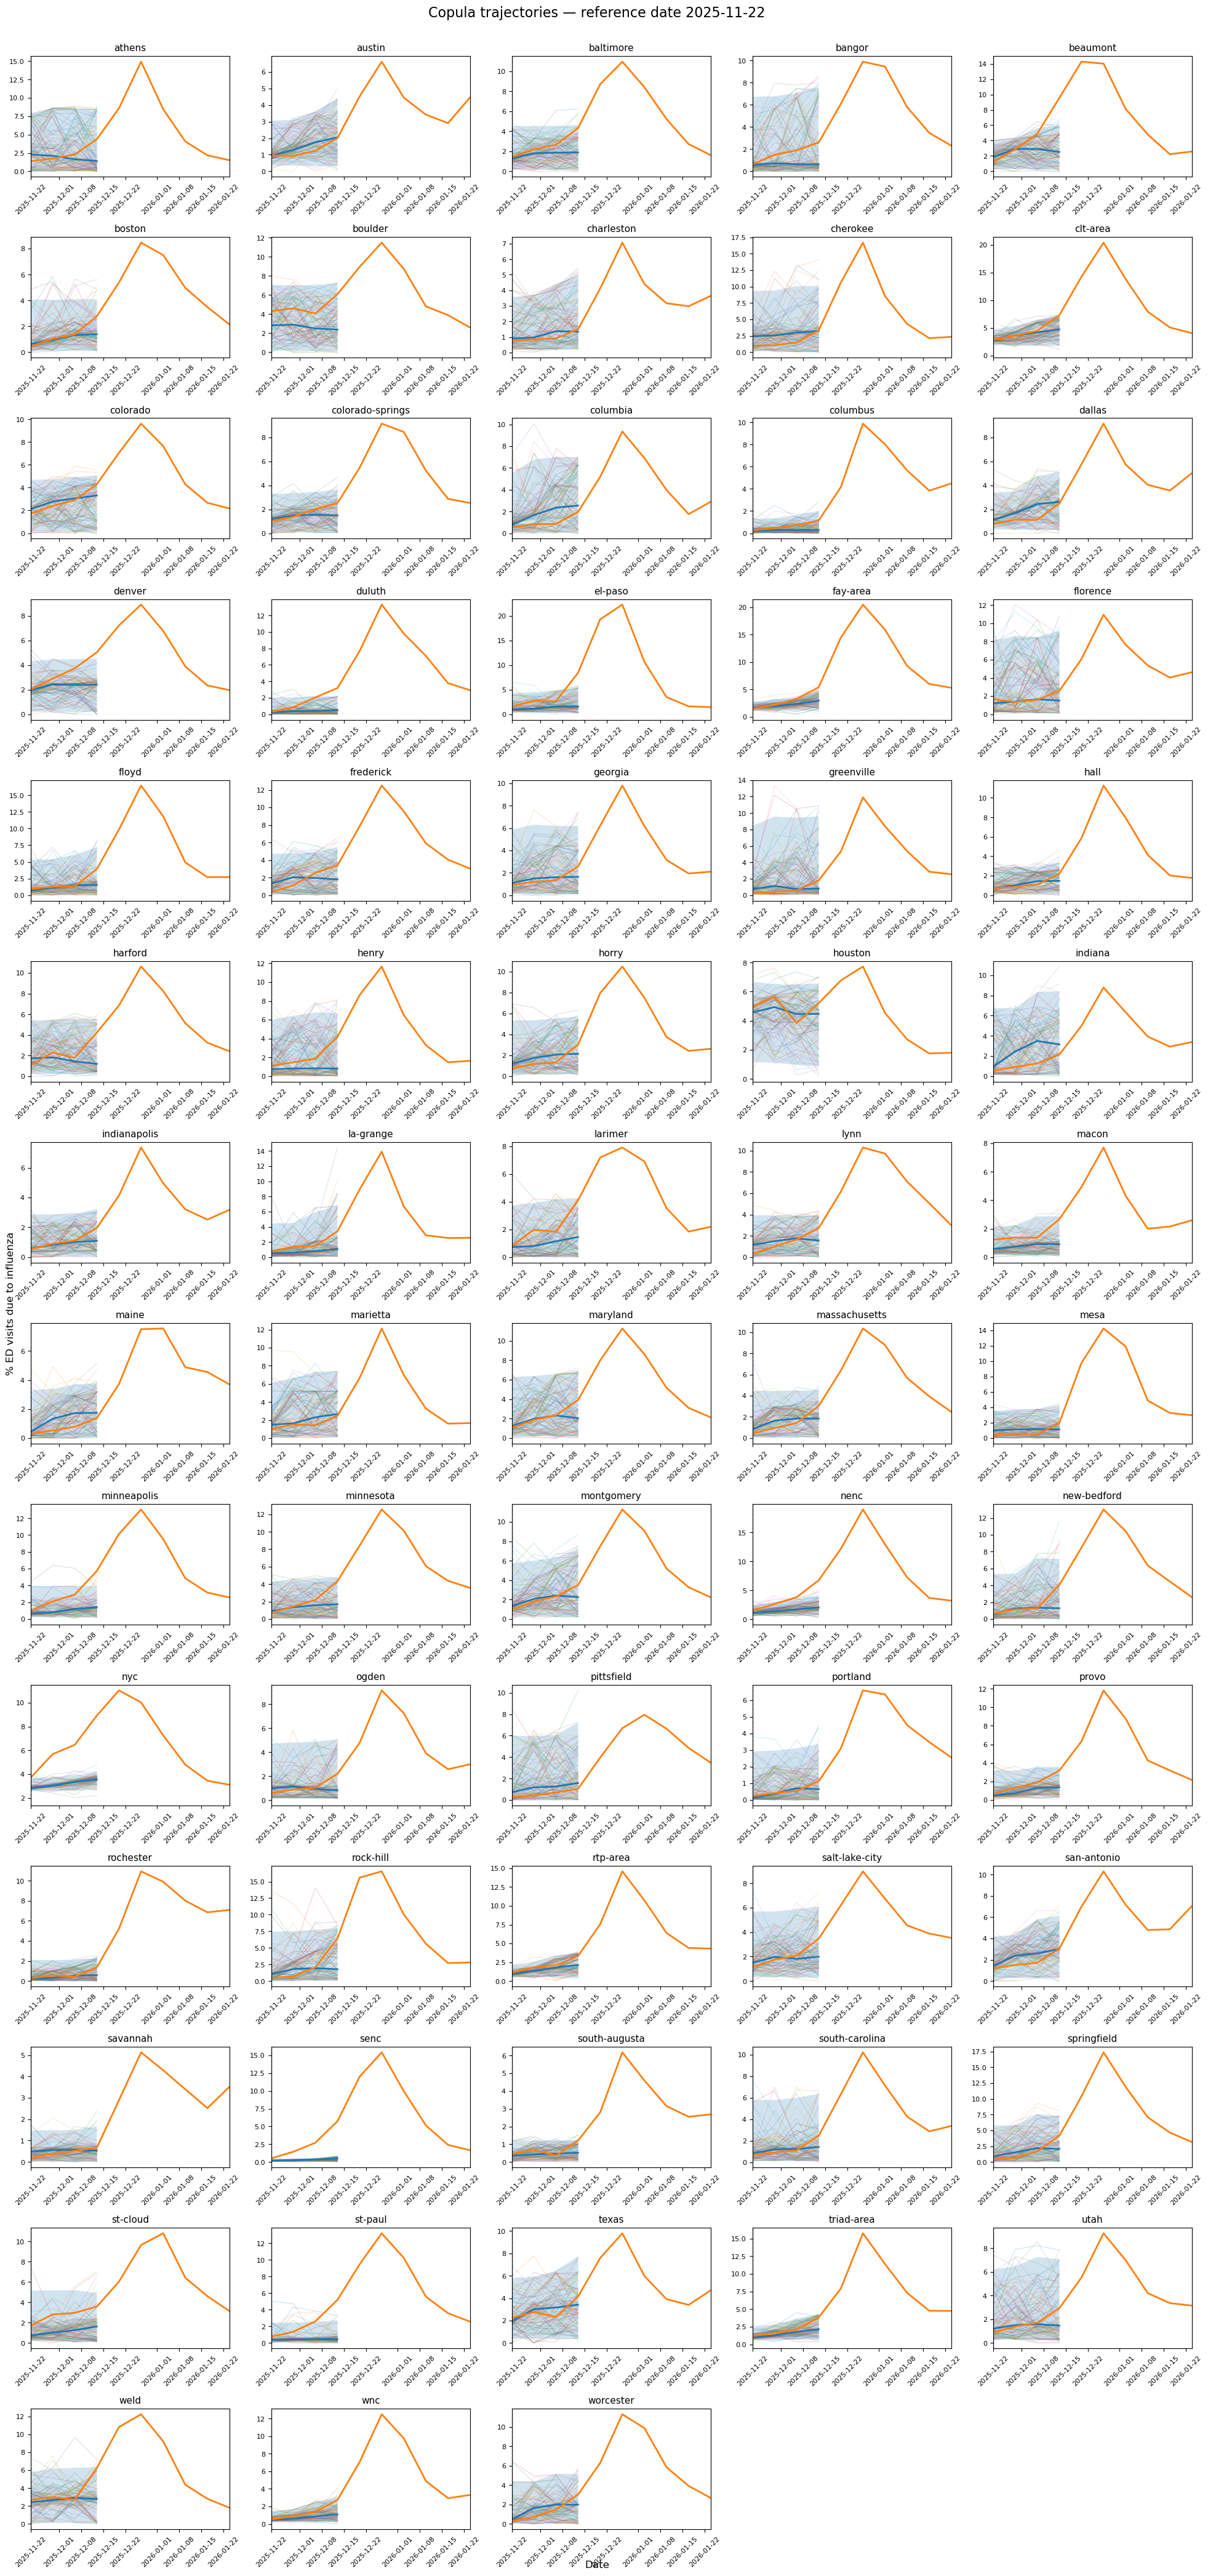

In [16]:
plot_all_copula_trajectories(
    forecasts=gbqr,
    observed=observed,
    trajectories=trajectories,
    reference_date=example_date
)

In [17]:
os.makedirs(output_dir, exist_ok=True)

# All reference dates
reference_dates = sorted(
    pd.to_datetime(gbqr["reference_date"].unique())
)

print("Number of reference dates:", len(reference_dates))

for reference_date in reference_dates:

    print(f"Processing {reference_date.date()}...")

    # Generate trajectories for all locations
    trajectories = generate_trajectories_for_date(
        forecasts=gbqr,
        reference_date=reference_date,
        Sigma=Sigma_hat,
        n_trajectories=100,
        seed=123
    )

    # Save one parquet per reference date
    date_string = reference_date.strftime("%Y-%m-%d")

    output_path = os.path.join(
        output_dir,
        f"{date_string}-UT-GBQR.parquet"
    )

    trajectories.to_parquet(
        output_path,
        index=False
    )

    print(
        f"  Saved: {len(trajectories):,} rows, "
        f"{trajectories['location'].nunique()} locations"
    )

Number of reference dates: 27
Processing 2025-11-22...
  Saved: 27,200 rows, 68 locations
Processing 2025-11-29...
  Saved: 3,600 rows, 9 locations
Processing 2025-12-06...
  Saved: 28,400 rows, 71 locations
Processing 2025-12-13...
  Saved: 28,400 rows, 71 locations
Processing 2025-12-20...
  Saved: 22,800 rows, 57 locations
Processing 2025-12-27...
  Saved: 28,400 rows, 71 locations
Processing 2026-01-03...
  Saved: 28,400 rows, 71 locations
Processing 2026-01-10...
  Saved: 28,400 rows, 71 locations
Processing 2026-01-17...
  Saved: 30,800 rows, 77 locations
Processing 2026-01-24...
  Saved: 30,800 rows, 77 locations
Processing 2026-01-31...
  Saved: 30,800 rows, 77 locations
Processing 2026-02-07...
  Saved: 30,800 rows, 77 locations
Processing 2026-02-14...
  Saved: 30,800 rows, 77 locations
Processing 2026-02-21...
  Saved: 30,800 rows, 77 locations
Processing 2026-02-28...
  Saved: 30,800 rows, 77 locations
Processing 2026-03-07...
  Saved: 30,800 rows, 77 locations
Processing 2

In [18]:
plot_date = "2026-01-03"

parquet_path = os.path.join(
    project_path,
    "model-output",
    "2627test",
    f"{plot_date}-UT-GBQR.parquet"
)

trajectories_plot = pd.read_parquet(parquet_path)

trajectories_plot.head()

,horizon,target_end_date,reference_date,location,trajectory_id,value
0,0,2026-01-03,2026-01-03,athens,0,11.448524
1,1,2026-01-10,2026-01-03,athens,0,11.886752
2,2,2026-01-17,2026-01-03,athens,0,11.194775
3,3,2026-01-24,2026-01-03,athens,0,6.222758
4,0,2026-01-03,2026-01-03,athens,1,11.390703


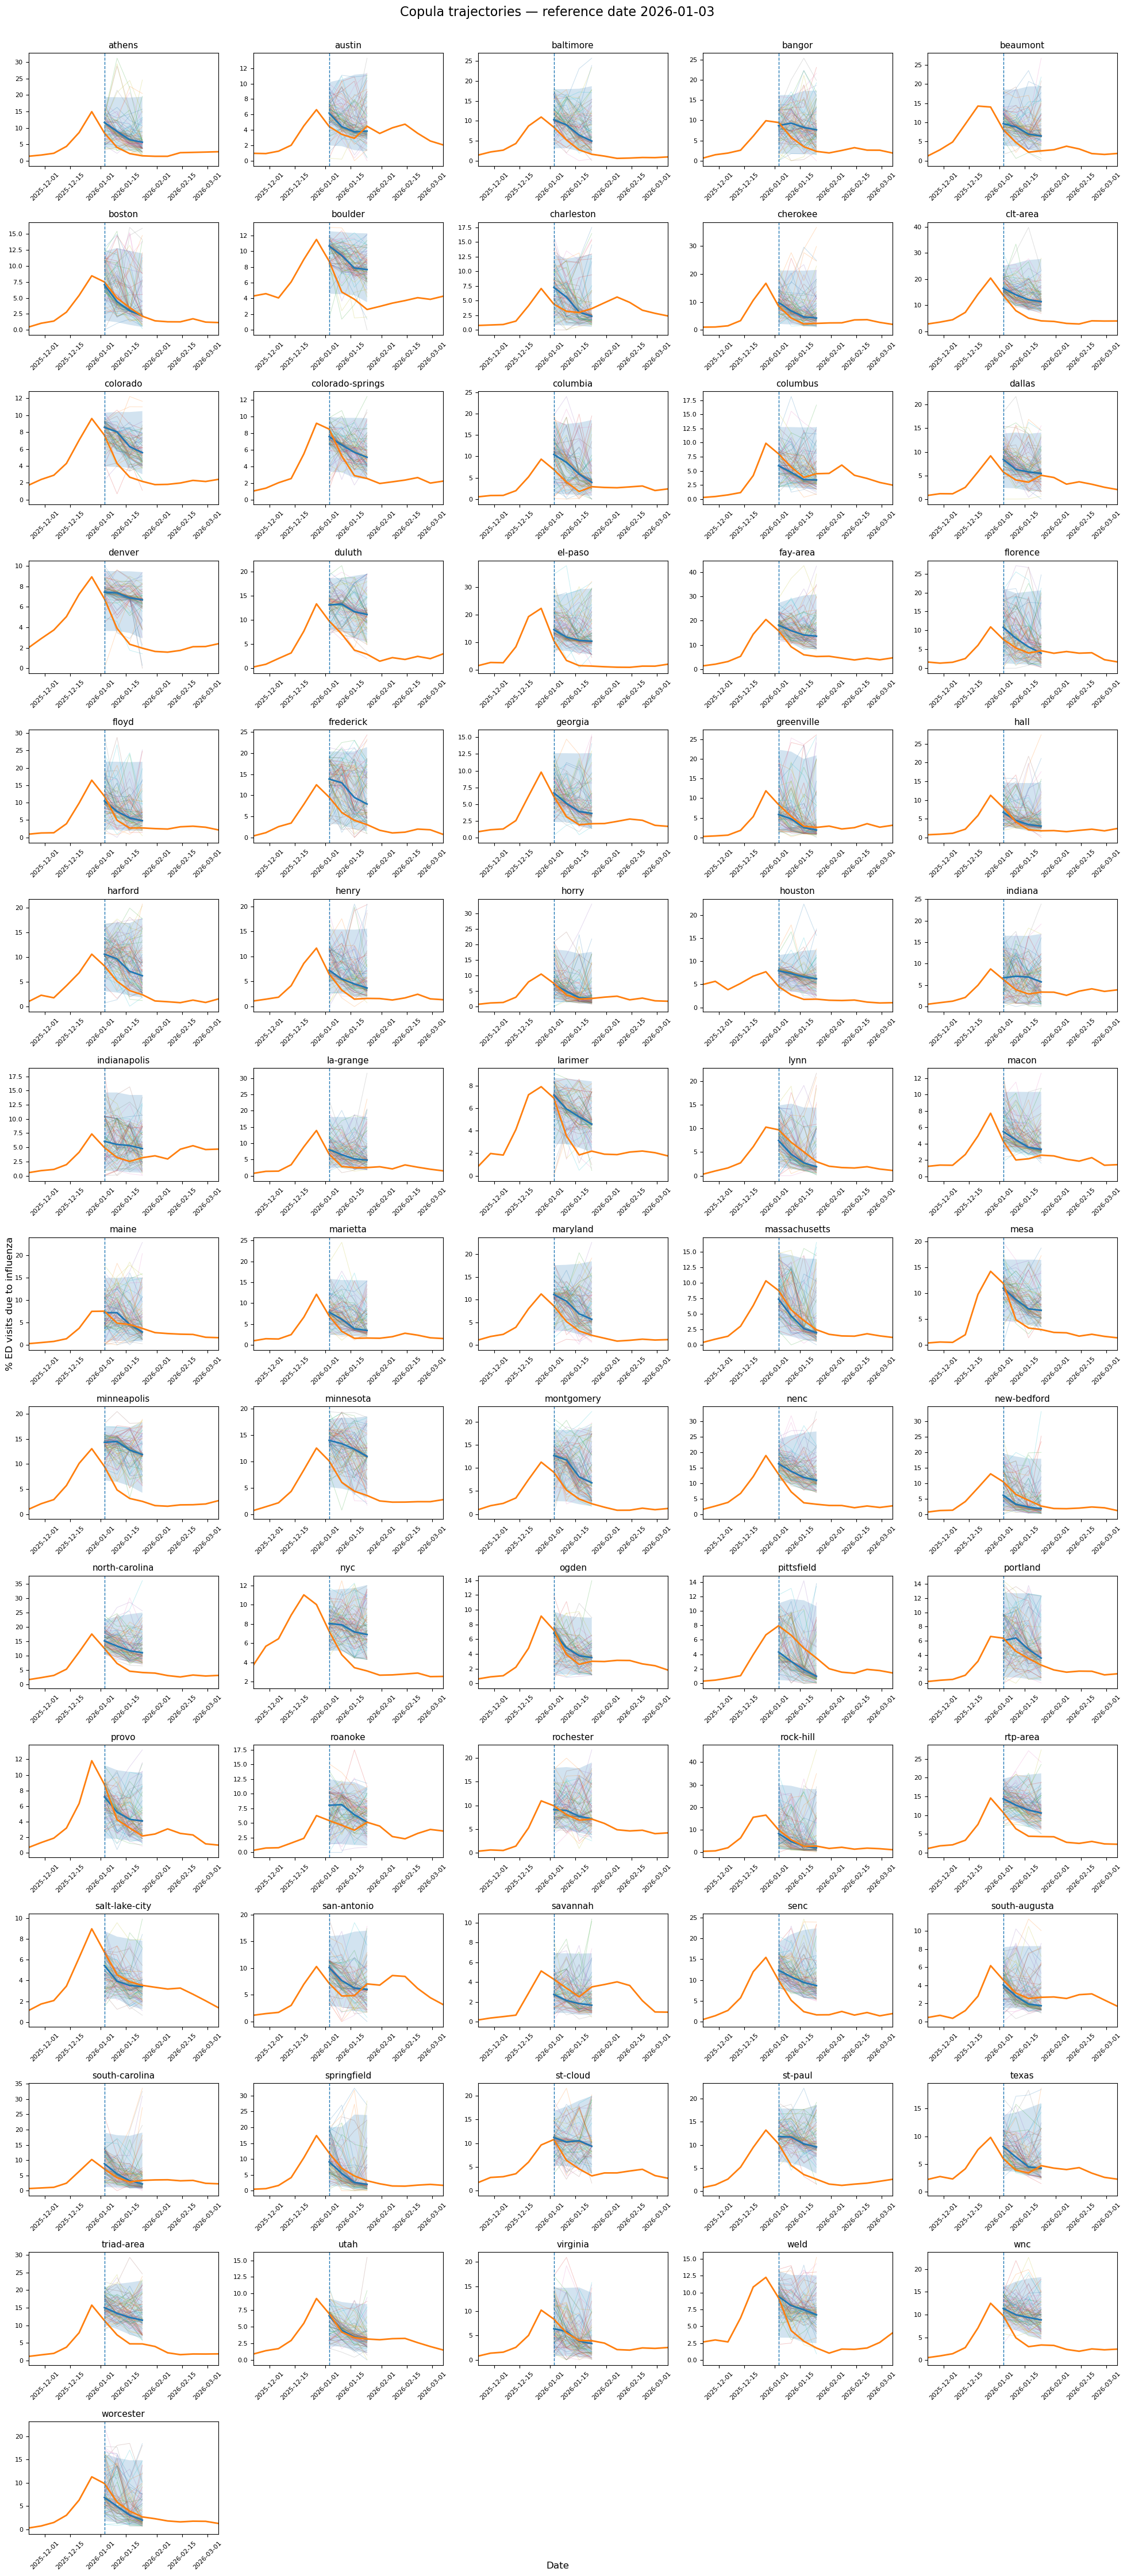

In [19]:
trajectories_plot["reference_date"] = pd.to_datetime(
    trajectories_plot["reference_date"]
)

trajectories_plot["target_end_date"] = pd.to_datetime(
    trajectories_plot["target_end_date"]
)

plot_date = pd.to_datetime(plot_date)

plot_all_copula_trajectories(
    forecasts=gbqr,
    observed=observed,
    trajectories=trajectories_plot,
    reference_date=plot_date
)